In [ ]:
import pandas as pd

!gdown 1yxgr0Qj3TiXRehYa0PED1t4zIga9gdY5

Downloading...
From: https://drive.google.com/uc?id=1yxgr0Qj3TiXRehYa0PED1t4zIga9gdY5
To: /content/churn_prediction.xlsx
100% 494k/494k [00:00<00:00, 39.9MB/s]


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import warnings
import time
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_excel(r"/content/churn_prediction.xlsx")

# **1. Data Preprocessing:**

In [ ]:
data.head(2)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,52869,0,20.0,Mobile Phone,3,7.0,E wallet,Female,4.0,4,Fashion,5,Married,3,0,26.0,5.0,16.0,NaN,229.53
1,52942,0,13.0,Computer,1,9.0,Cash on Delivery,Female,4.0,4,Fashion,3,Single,2,0,26.0,11.0,NaN,9.0,234.38


In [ ]:
#kiểm tra data có bao nhiêu dòng, bao nhiêu cột
print(data.shape)
#kiểm tra thông tin dtype của data
data.info()

(5630, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberO

In [ ]:
# Change all column names to lowercase for easy to mention:
data.columns = data.columns.str.lower()

In [ ]:
# Check imbalance data:
imb_data = data.groupby('churn')['customerid'].count().reset_index()
imb_data['%'] = imb_data['customerid']/sum(imb_data['customerid'])
imb_data

,churn,customerid,%
0,0,4682,0.831616
1,1,948,0.168384


In [ ]:
data.shape

(5630, 20)

→ Data is not much imbalanced → Acceptable

# 1.1 Missing values:

<Axes: >

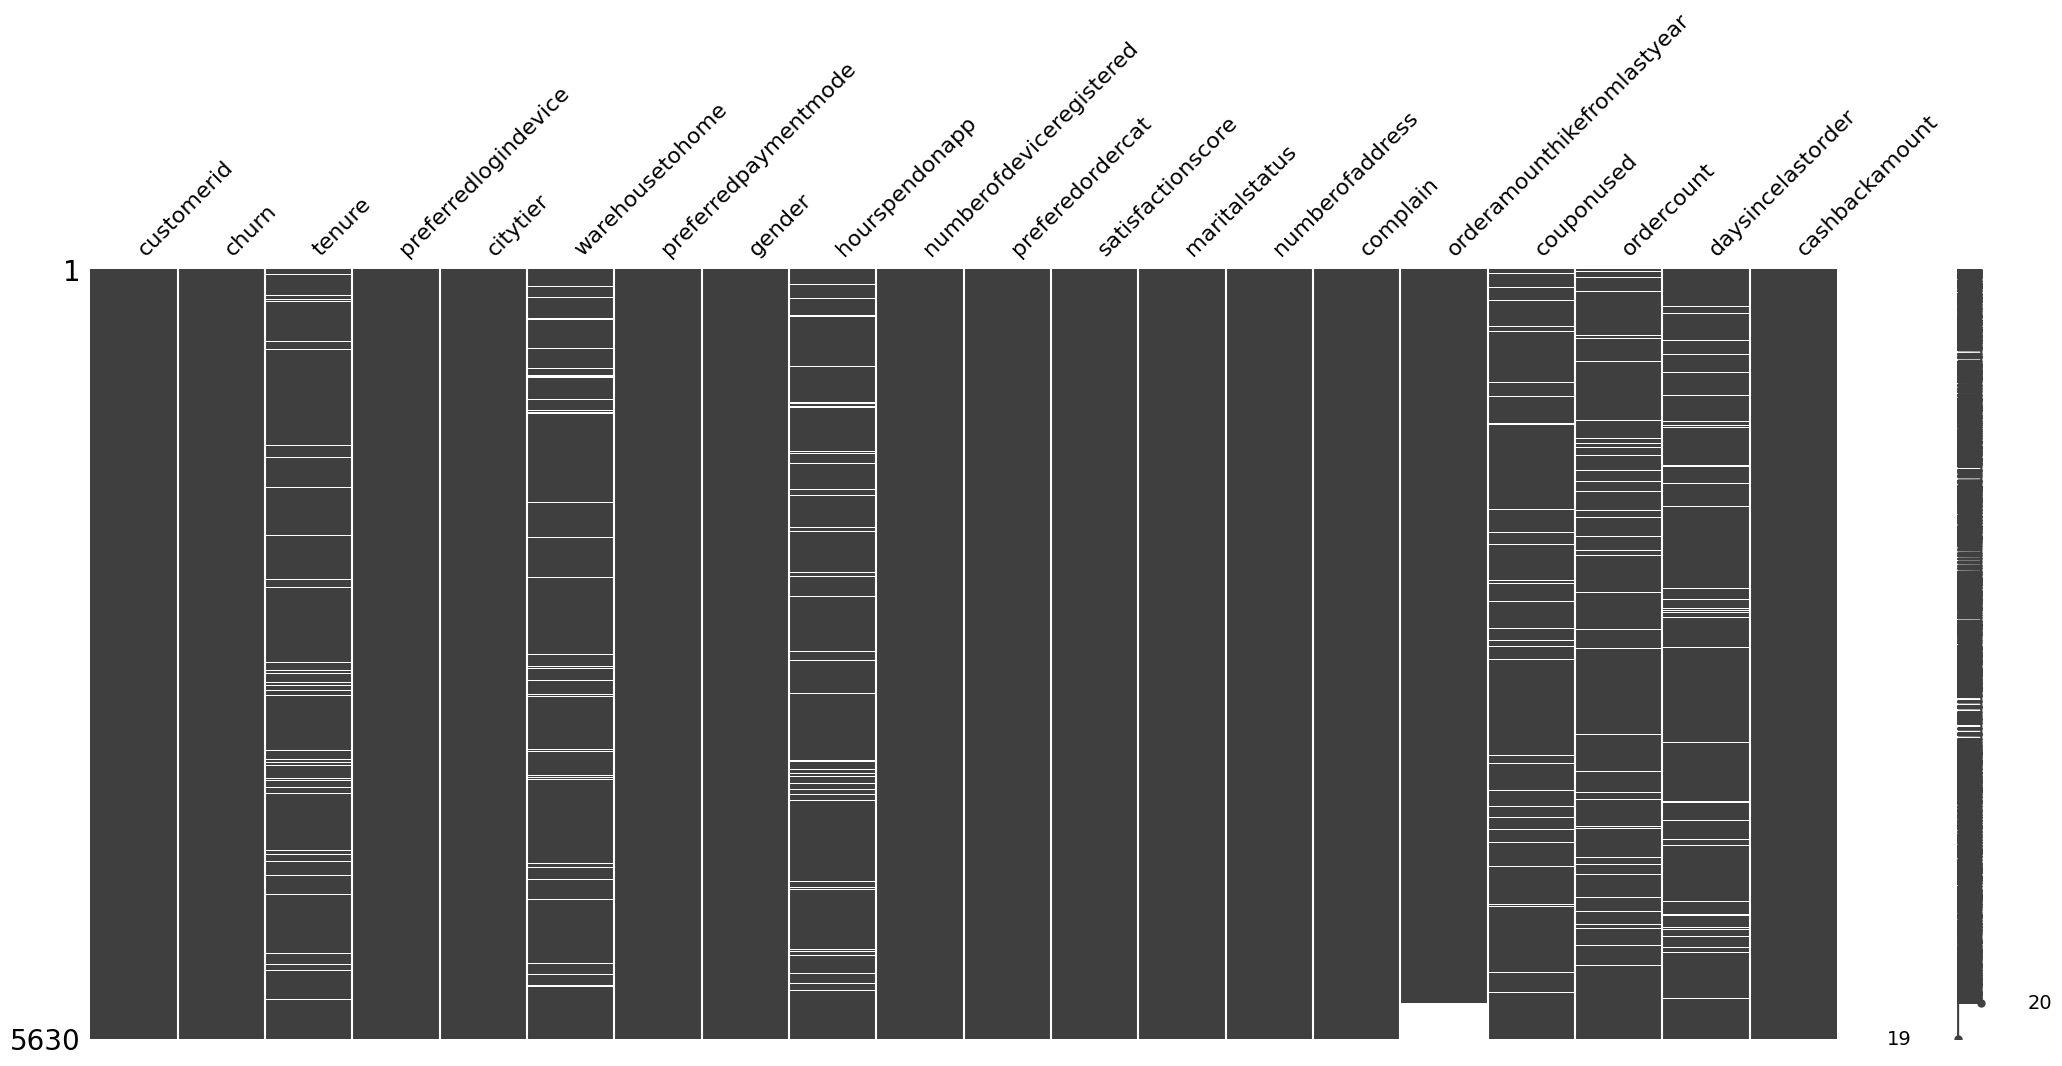

In [ ]:
import missingno as msno
msno.matrix(data)

In [ ]:
# Check dtypes of columns has missing values:
list_null = data.columns[data.isnull().any()].tolist()
data[list_null].dtypes

,0
tenure,float64
warehousetohome,float64
hourspendonapp,float64
orderamounthikefromlastyear,float64
couponused,float64
ordercount,float64
daysincelastorder,float64


In [ ]:
missing_rows_percentage = data.isnull().any(axis=1).mean()*100

print (f"Tỉ lệ số dòng có missing values: {missing_rows_percentage}")

Tỉ lệ số dòng có missing values: 32.96625222024866


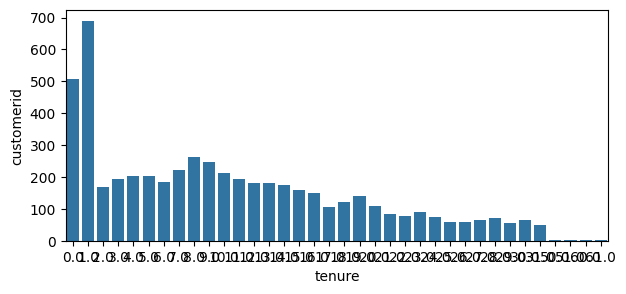

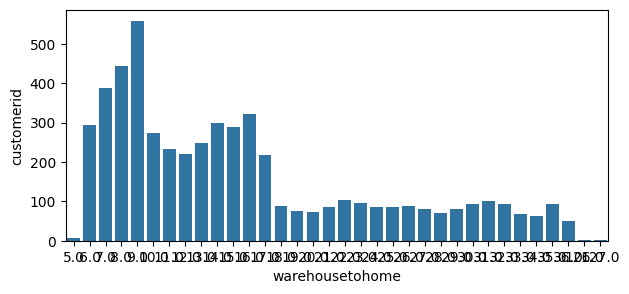

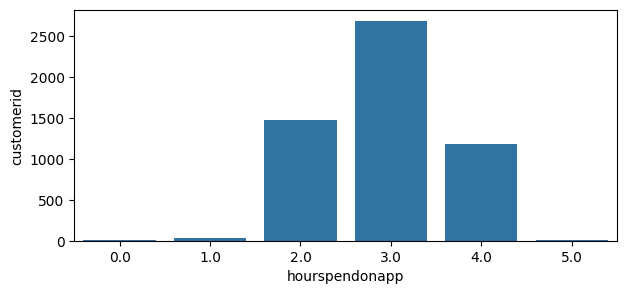

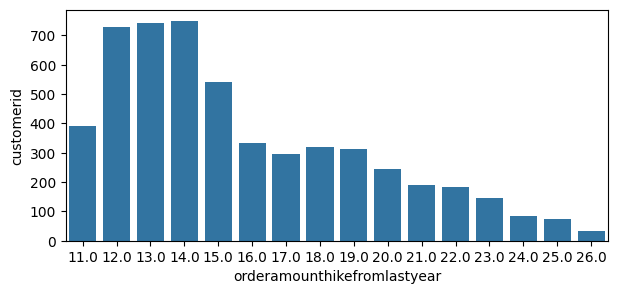

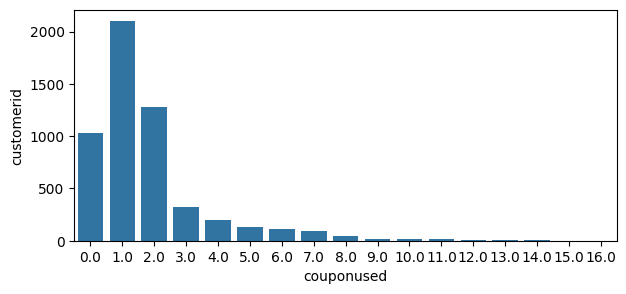

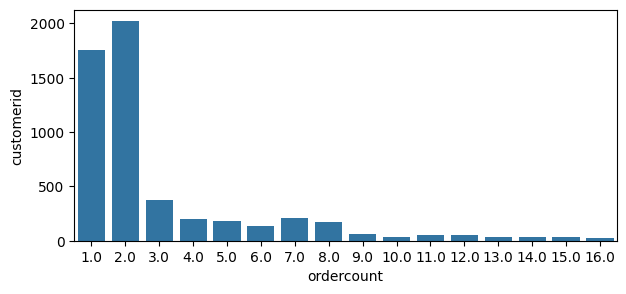

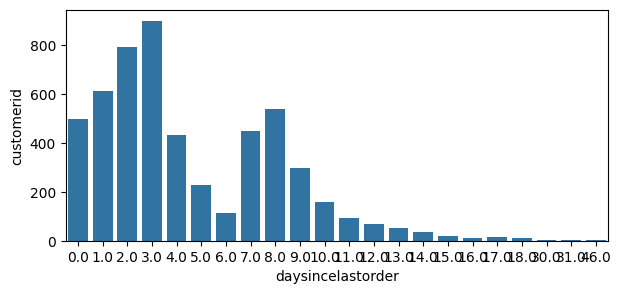

In [ ]:
# Check the distribution to decide we will replace with median or 0:
for i in list_null:
    fig, ax = plt.subplots(figsize=(7, 3))
    plot_data = data.groupby(i)[['customerid']].count().reset_index()
    sns.barplot(data = plot_data,x=plot_data[i],y= plot_data['customerid'],ax=ax)
    plt.show()

After review the distribution, we will replace:
   * The decision was made based on: the meaning of columns and the distribution
        - tenure: median
        - warehousetohome: median
        - hourspendonapp: 0
        - orderamounthikefromlastyear: median
        - couponused: 0
        - ordercount: median
        - daysincelastorder: median

<Axes: >

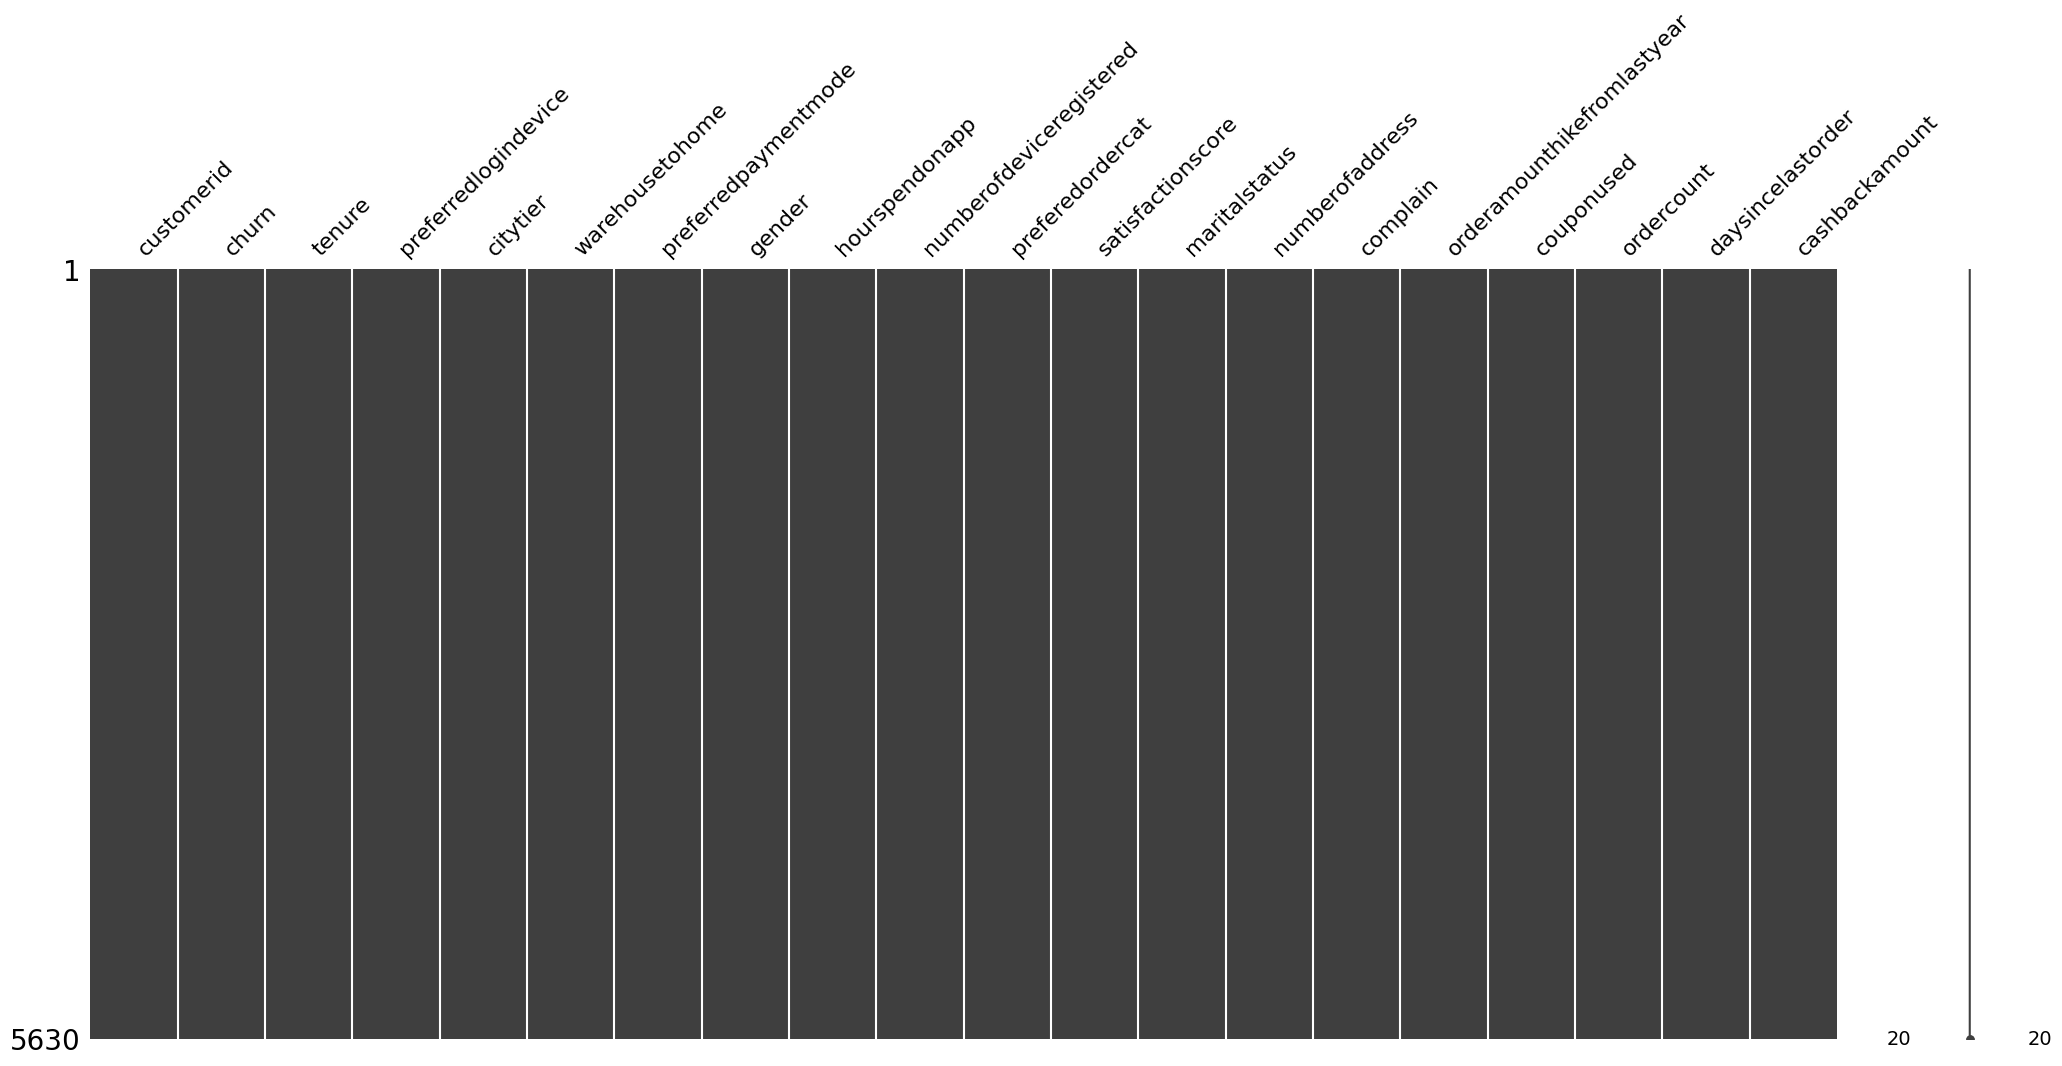

In [ ]:
def replace_func(list_columns):
    for i in list_columns:
        if i in ['tenure','warehousetohome','orderamounthikefromlastyear','ordercount','daysincelastorder']:
            median = data[i].median()
            data[i].fillna(median, inplace=True)
        else:
            data[i].fillna(0, inplace=True)

replace_func(list_null)
msno.matrix(data)

# 1.2 Duplicated Values:

In [ ]:
data.duplicated().any()

np.False_

# 1.3 Check same meaning values:

In [ ]:
#Check the unique values:
list_obj =data.loc[:, data.dtypes == object].columns.tolist()
for i in list_obj:
  print(f"Unique values of {i}: {data[i].unique()}")

Unique values of preferredlogindevice: ['Mobile Phone' 'Computer' 'Phone']
Unique values of preferredpaymentmode: ['E wallet' 'Cash on Delivery' 'Debit Card' 'UPI' 'Credit Card' 'COD' 'CC']
Unique values of gender: ['Female' 'Male']
Unique values of preferedordercat: ['Fashion' 'Laptop & Accessory' 'Mobile Phone' 'Grocery' 'Mobile' 'Others']
Unique values of maritalstatus: ['Married' 'Single' 'Divorced']


In [ ]:
#Replace the same meaning values:
data['preferredlogindevice'] = data['preferredlogindevice'].replace({'Mobile Phone':'Phone'})
data['preferredpaymentmode'] = data['preferredpaymentmode'].replace({'CC':'Credit Card','COD':'Cash on Delivery'})
data['preferedordercat'] = data['preferedordercat'].replace({'Mobile Phone':'Phone'})

#Recheck:
for i in list_obj:
  print(f"Unique values of {i}: {data[i].unique()}")

Unique values of preferredlogindevice: ['Phone' 'Computer']
Unique values of preferredpaymentmode: ['E wallet' 'Cash on Delivery' 'Debit Card' 'UPI' 'Credit Card']
Unique values of gender: ['Female' 'Male']
Unique values of preferedordercat: ['Fashion' 'Laptop & Accessory' 'Phone' 'Grocery' 'Mobile' 'Others']
Unique values of maritalstatus: ['Married' 'Single' 'Divorced']


In [ ]:
# Encoding
categorical_cols = data.loc[:, data.dtypes == object].columns.tolist()
categorical_cols


['preferredlogindevice',
 'preferredpaymentmode',
 'gender',
 'preferedordercat',
 'maritalstatus']

In [ ]:
data_encoded = data.copy()
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [ ]:
# RANDOM FOREST MODEL
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
x = data_encoded.drop(['churn', 'customerid'], axis=1)
y = data_encoded['churn']
# Tách Train vs Test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# Sử dụng MinMaxScaler để normalize các features của x:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

print(f'Balance accuracy of test set: {balanced_accuracy_score(y_test, y_pred)}')

Balance accuracy of test set: 0.8981711681683815


In [ ]:
#Show features
feature_importance = pd.DataFrame({
    'feature': x.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
                                feature  importance
22              preferedordercat_Others    0.002152
19             preferedordercat_Grocery    0.003428
17             preferredpaymentmode_UPI    0.005965
21              preferedordercat_Mobile    0.008985
16        preferredpaymentmode_E wallet    0.010922
23               preferedordercat_Phone    0.011909
15      preferredpaymentmode_Debit Card    0.014646
14     preferredpaymentmode_Credit Card    0.015254
24                maritalstatus_Married    0.015555
20  preferedordercat_Laptop & Accessory    0.016769
18                          gender_Male    0.017475
13           preferredlogindevice_Phone    0.019937
3                        hourspendonapp    0.020514
25                 maritalstatus_Single    0.023207
1                              citytier    0.026469
9                            couponused    0.027661
10                           ordercount    0.031674
4              numberofdeviceregistered    

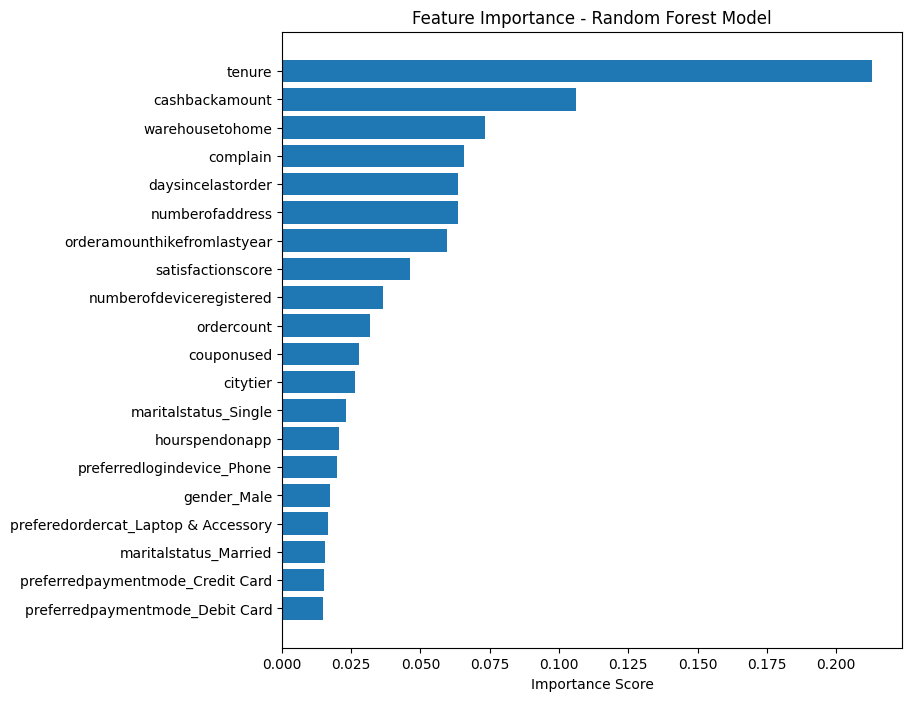

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.barh(feature_importance.tail(20)['feature'], feature_importance.tail(20)['importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance - Random Forest Model')
plt.show()

As Feature Importance show, we can see these features can have high relation with target columns:
* Tenure
* Cashback amount
* Distance from warehouse to home
* Complain
* Days since Last order

&rarr; We will analyse and visualize these features for more insights.


#### **1.4 Analyse features from initial Random Forest model:**

* Tenure
* Cashback amount
* Distance from warehouse to home
* Complain
* Days since Last order

In [ ]:
def count_percentage(df, column, target, count):
    '''
    This function to create the table calculate the percentage of fraud/non-fraud
    transaction on total transaction group by category values
    '''

    # Create 2 dataframes of fraud and non-fraud
    fraud = df[df[target]==1].groupby(column)[[count]].count().reset_index().sort_values(ascending=False, by = count)
    not_fraud = df[df[target]==0].groupby(column)[[count]].count().reset_index().sort_values(ascending=False, by = count)

    #Merge 2 dataframe into one:
    cate_df = fraud.merge(not_fraud, on = column , how = 'outer')
    cate_df = cate_df.fillna(0)
    cate_df.rename(columns = {count+'_x':'fraud',count+'_y':'not_fraud'}, inplace = True)

    #Caculate the percentage:
    cate_df['%'] = cate_df['fraud']/(cate_df['fraud']+cate_df['not_fraud'])
    cate_df = cate_df.sort_values(by='%', ascending=False)

    return cate_df

In [ ]:
churned = data[data['churn'] == 1].copy()
retained = data[data['churn'] == 0].copy()

##### **1.4.1 Tenure**  New users are churned more than old users (tenure = 0 or 1)

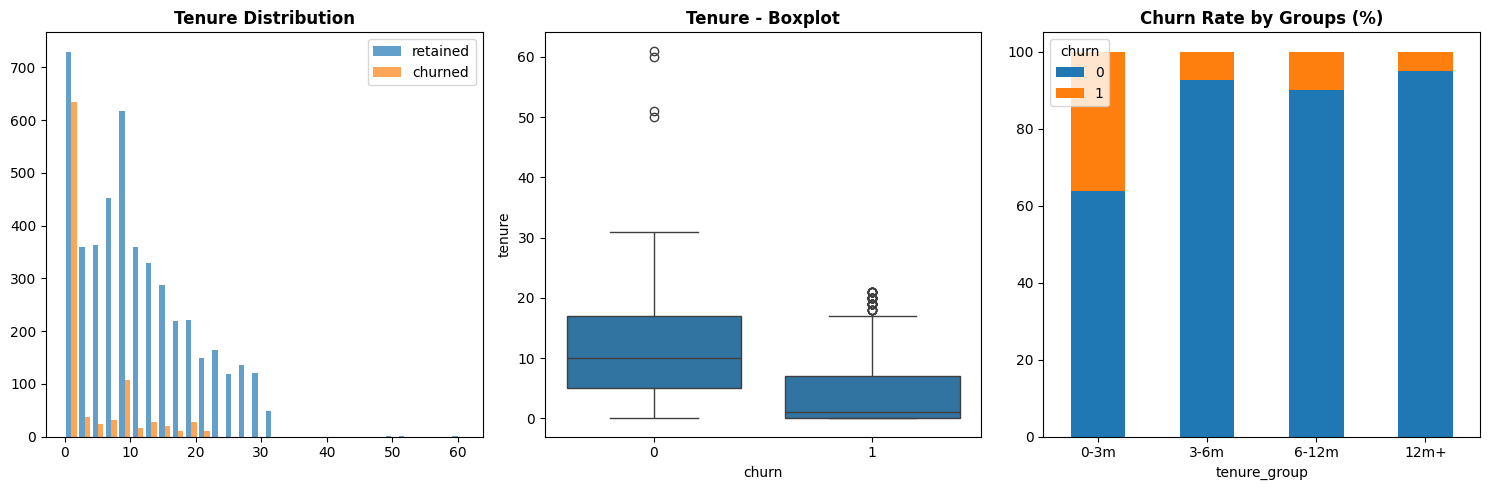

In [ ]:
plt.figure(figsize=(15, 5))

# 1. Histogram
plt.subplot(1, 3, 1)
plt.hist([retained['tenure'].dropna(), churned['tenure'].dropna()],
         bins=30, label=['retained', 'churned'], alpha=0.7)
plt.title('Tenure Distribution', fontweight='bold')
plt.legend()

# 2. Boxplot
plt.subplot(1, 3, 2)
# Dùng trực tiếp data và cột churn để vẽ
sns.boxplot(x='churn', y='tenure', data=data) # Dùng seaborn sẽ đẹp và gọn hơn
plt.title('Tenure - Boxplot', fontweight='bold')

# 3. Bar chart theo nhóm
plt.subplot(1, 3, 3)
data['tenure_group'] = pd.cut(data['tenure'], bins=[0, 3, 6, 12, 100],
                               labels=['0-3m', '3-6m', '6-12m', '12m+'])
tenure_churn = pd.crosstab(data['tenure_group'], data['churn'], normalize='index') * 100
tenure_churn.plot(kind='bar', stacked=True, ax=plt.gca()) # stacked=True nhìn tỉ lệ tổng quan hơn
plt.title('Churn Rate by Groups (%)', fontweight='bold')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Insight: We are losing most customers in a 90-day. However, if we can push users past the 3-month mark, the churn rate stabilizes below 10%, creating a highly predictable and loyal revenue stream.

##### **1.4.2 Cashback amount**  Churn users recevied cashback amount less than not churn users.

CASHBACK AMOUNT
   Churned - Mean: $160.37
   Retained - Mean: $180.64
   Difference: $20.26


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Low (<$150)'),
  Text(1, 0, 'Medium ($150-175)'),
  Text(2, 0, 'High ($175-200)'),
  Text(3, 0, 'Very High ($200+)')])

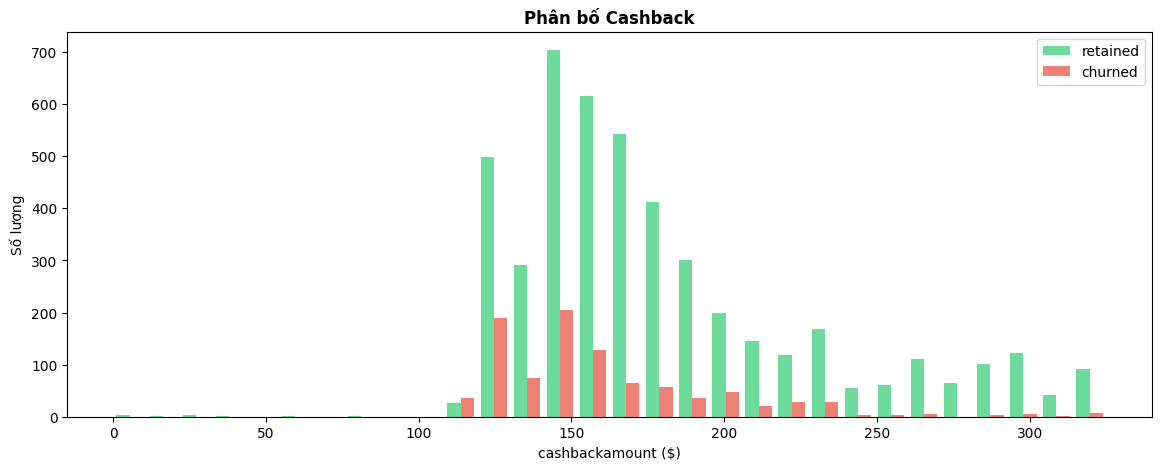

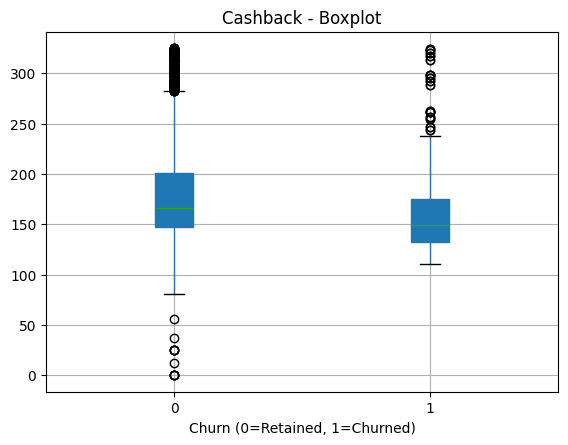

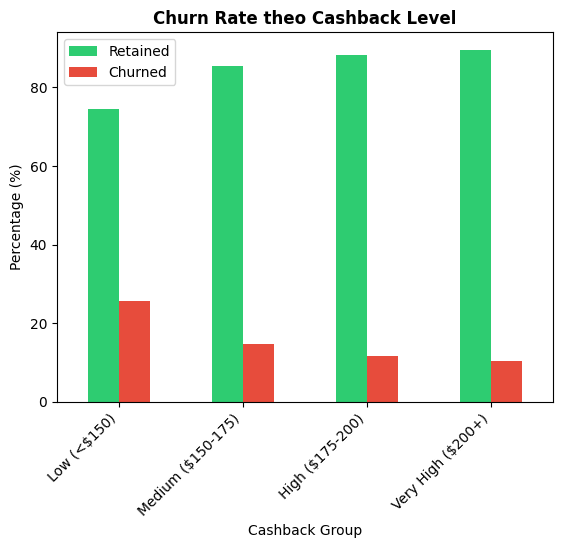

In [ ]:
print("CASHBACK AMOUNT")
print(f"   Churned - Mean: ${churned['cashbackamount'].mean():.2f}")
print(f"   Retained - Mean: ${retained['cashbackamount'].mean():.2f}")
print(f"   Difference: ${retained['cashbackamount'].mean() - churned['cashbackamount'].mean():.2f}")

plt.figure(figsize=(14, 5))
plt.subplot()
plt.hist([retained['cashbackamount'].dropna(), churned['cashbackamount'].dropna()],
         bins=30, label=['retained', 'churned'], color=['#2ecc71', '#e74c3c'], alpha=0.7)
plt.xlabel('cashbackamount ($)')
plt.ylabel('Số lượng')
plt.title('Phân bố Cashback', fontweight='bold')
plt.legend()

plt.subplot()
data.boxplot(column='cashbackamount', by='churn', patch_artist=True)
plt.title('Cashback - Boxplot')
plt.suptitle('')
plt.xlabel('Churn (0=Retained, 1=Churned)')

data['Cashback_Group'] = pd.cut(data['cashbackamount'], bins=[0, 150, 175, 200, 500],
                                 labels=['Low (<$150)', 'Medium ($150-175)', 'High ($175-200)', 'Very High ($200+)'])
cashback_churn = pd.crosstab(data['Cashback_Group'], data['churn'], normalize='index') * 100
cashback_churn.plot(kind='bar', stacked=False, color=['#2ecc71', '#e74c3c'])
plt.title('Churn Rate theo Cashback Level', fontweight='bold')
plt.xlabel('Cashback Group')
plt.ylabel('Percentage (%)')
plt.legend(['Retained', 'Churned'])
plt.xticks(rotation=45, ha='right')

Churn users recevied cashback amount less than not churn users.

##### **1.4.3 Warehouse to home**  Not significantly related

3. WAREHOUSE TO HOME 
   Churned - Mean: 16.86 km
   Retained - Mean: 15.31 km


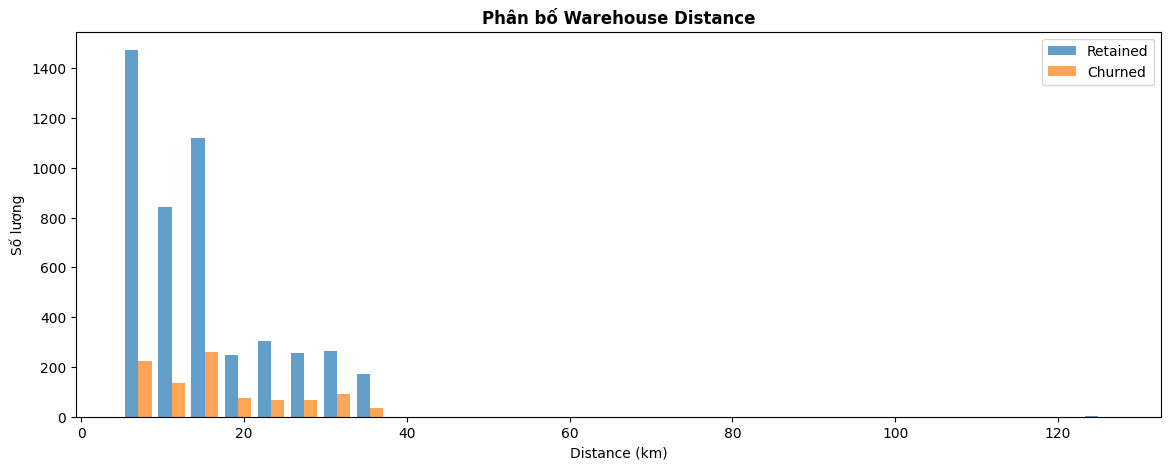

<Figure size 600x600 with 0 Axes>

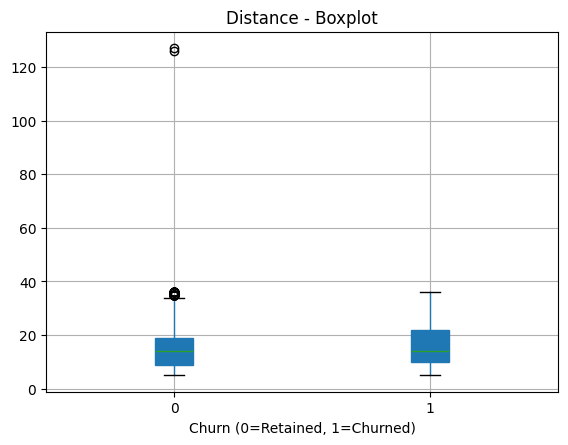

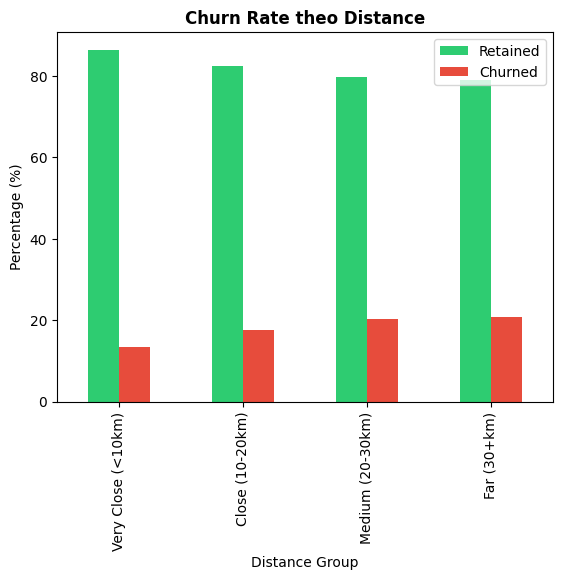

In [ ]:
print("3. WAREHOUSE TO HOME ")
print(f"   Churned - Mean: {churned['warehousetohome'].mean():.2f} km")
print(f"   Retained - Mean: {retained['warehousetohome'].mean():.2f} km")

plt.figure(figsize=(14, 5))
plt.subplot()
plt.hist([retained['warehousetohome'].dropna(), churned['warehousetohome'].dropna()],
         bins=30, label=['Retained', 'Churned'], alpha=0.7)
plt.xlabel('Distance (km)')
plt.ylabel('Số lượng')
plt.title('Phân bố Warehouse Distance', fontweight='bold')
plt.legend()

plt.figure(figsize=(6, 6))
data.boxplot(column='warehousetohome', by='churn', patch_artist=True, )
plt.title('Distance - Boxplot')
plt.suptitle('')
plt.xlabel('Churn (0=Retained, 1=Churned)')

data['Distance_Group'] = pd.cut(data['warehousetohome'], bins=[0, 10, 20, 30, 100],
                                 labels=['Very Close (<10km)', 'Close (10-20km)', 'Medium (20-30km)', 'Far (30+km)'])
distance_churn = pd.crosstab(data['Distance_Group'], data['churn'], normalize='index') * 100
distance_churn.plot(kind='bar', stacked=False, color=['#2ecc71', '#e74c3c'])
plt.title('Churn Rate theo Distance', fontweight='bold')
plt.xlabel('Distance Group')
plt.ylabel('Percentage (%)')
plt.legend(['Retained', 'Churned'])

For both churn & not churn:
* The median, pt25, mean, pt75 is quite the same --> The centralize of data is the same
* For not churn, data has some outliers --> This can be not significant enough to consider it as an insight for not churn

&rarr; There're no strong evidences show that there different between churn and not churn for warehousetohome --> We will exclude this features when apply model for not being bias.

##### **1.4.4 Days since last order:** churn users with complain = 1 have higher days since orders than churned users with complain = 0  

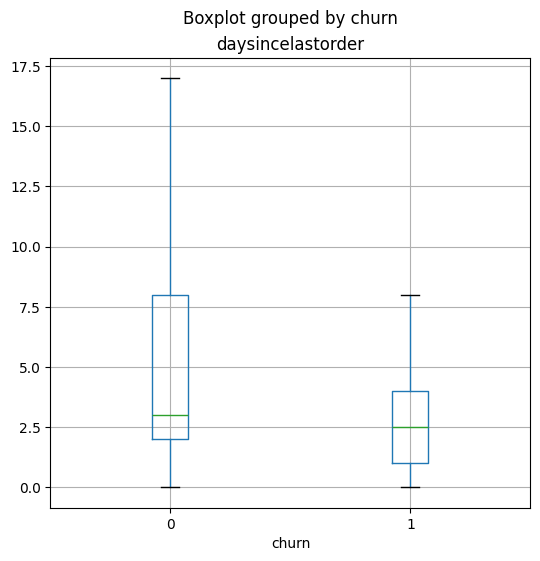

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
data.boxplot(column='daysincelastorder', by='churn', ax=ax, showfliers=False)
plt.show()

From this chart, we see for churned users, they had orders recently (the day since last order less than not churned users) --> This quite strange, we should monitor more features for this insight (satisfaction_score, complain,..)

<Axes: title={'center': 'daysincelastorder'}, xlabel='complain'>

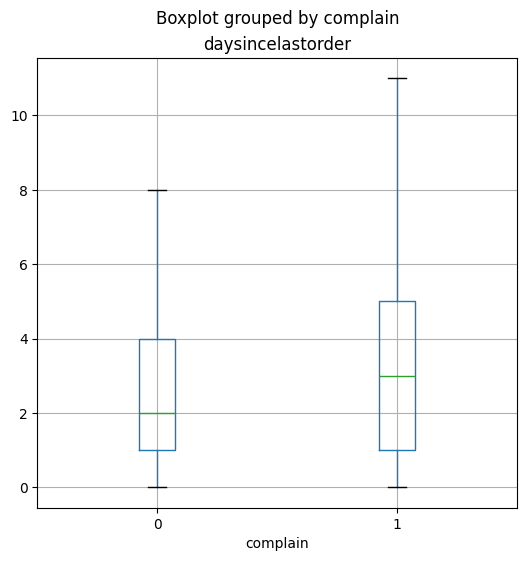

In [ ]:
churn_df = data[data['churn'] == 1]
fig, ax = plt.subplots(figsize=(6, 6))

churn_df.boxplot(column='daysincelastorder', by='complain', ax=ax, showfliers=False)

For churned users with complain = 1, they had daysincelastorder higher than churn users with compain = 0

##### **1.4.5 Complain** The number of users complain on churn is higher than not churn

<Axes: xlabel='complain', ylabel='%'>

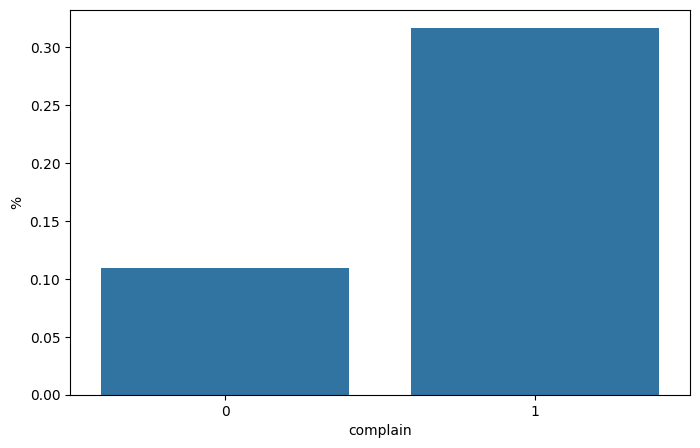

In [ ]:
plot_data = count_percentage(data, 'complain', 'churn', 'customerid')
#Visualize the data:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=plot_data, x='complain',y='%', ax=ax)

##### **1.4.6 Conclusion & Suggestion**

1. Churned users usually are new users &rarr; Provide more promotion for new users, or increase the new users experience
2. Churned users usually receive less cashback than not churn &rarr; Increase the cashback ratio
3. Churned users complain more &rarr; deep dive what these churned users complain about, and provide the solution

## **Question 2:**

1. Remove warehousetohome column
2. Apply Random Forest model and fine tuning

### **2. Feature Transforming:**

In [ ]:
# Remove
data_model = data.drop(columns=['tenure_group', 'Cashback_Group', 'Distance_Group','warehousetohome'])
data_model.head(1)

,customerid,churn,tenure,preferredlogindevice,citytier,preferredpaymentmode,gender,hourspendonapp,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount
0,52869,0,20.0,Phone,3,E wallet,Female,4.0,4,Fashion,5,Married,3,0,26.0,5.0,16.0,3.0,229.53


In [ ]:
cate_columns = data_model.loc[:, data_model.dtypes == object].columns.tolist()
encoded_data = pd.get_dummies(data_model, columns = cate_columns,drop_first=True)
encoded_data.shape

(5630, 27)

In [ ]:
encoded_data.head(3)

,customerid,churn,tenure,citytier,hourspendonapp,numberofdeviceregistered,satisfactionscore,numberofaddress,complain,orderamounthikefromlastyear,...,preferredpaymentmode_E wallet,preferredpaymentmode_UPI,gender_Male,preferedordercat_Grocery,preferedordercat_Laptop & Accessory,preferedordercat_Mobile,preferedordercat_Others,preferedordercat_Phone,maritalstatus_Married,maritalstatus_Single
0,52869,0,20.0,3,4.0,4,5,3,0,26.0,...,True,False,False,False,False,False,False,False,True,False
1,52942,0,13.0,1,4.0,4,3,2,0,26.0,...,False,False,False,False,False,False,False,False,False,True
2,52972,0,16.0,3,3.0,4,3,3,0,26.0,...,False,False,True,False,True,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

x=encoded_data.drop(['churn','customerid'], axis = 1)
y=encoded_data[['churn']]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

x_train, x_temp, y_train, y_temp = train_test_split(x,y, test_size=0.3, random_state=42)

x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

# x_temp, x_test, y_temp, y_test = train_test_split(x,y, test_size=0.15, random_state=42)

# x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.1764, random_state=42)

# Print the sizes of the splits
print(f"Training set size: {len(x_train)}")
print(f"Validation set size: {len(x_val)}")
print(f"Test set size: {len(x_test)}")



Training set size: 3941
Validation set size: 844
Test set size: 845


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_val_scaled=scaler.transform(x_val)
x_test_scaled=scaler.transform(x_test)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "DecisionTree": DecisionTreeClassifier(max_depth=5),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}


results = []

for name, model in models.items():
    model.fit(x_train, y_train)

    y_pred = model.predict(x_val)
    y_proba = model.predict_proba(x_val)[:, 1]

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    bal_acc = balanced_accuracy_score(y_val, y_pred)

    results.append({
        "model": name,
        "precision": precision,
        "recall": recall,
        "balanced_accuracy": bal_acc
    })

results_df = pd.DataFrame(results).sort_values("balanced_accuracy", ascending=False)
print(results_df)

                model  precision    recall  balanced_accuracy
2        RandomForest   0.907563  0.724832           0.854502
3    GradientBoosting   0.786408  0.543624           0.755985
0  LogisticRegression   0.680000  0.456376           0.705166
1        DecisionTree   0.820513  0.429530           0.704693


#### **3.3 Enhance Random Forest model**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
clf_rand = RandomForestClassifier(random_state=0)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [20, 30,40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Use GridSearchCV to find the best parameters
grid_search = GridSearchCV(clf_rand, param_grid, cv=5, scoring='balanced_accuracy')

# Fit the model
grid_search.fit(x_train, y_train)

# Print the best parameters
print("Best Parameters: ", grid_search.best_params_)

# Evaluate the best model on the test set
best_clf = grid_search.best_estimator_
print(best_clf)

Best Parameters:  {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
RandomForestClassifier(bootstrap=False, max_depth=20, random_state=0)


**Re-apply model with new parameters:**

In [ ]:
best_params = grid_search.best_params_
clf_rand_after = RandomForestClassifier(**best_params,random_state=0)

clf_rand_after.fit(x_train_scaled, y_train)
y_ranf_aft_train = clf_rand_after.predict(x_train_scaled)
y_ranf_aft_val = clf_rand_after.predict(x_val_scaled)

In [ ]:
print(f'Balance accuracy of train set: {balanced_accuracy_score(y_train, y_ranf_aft_train)}')
print(f'Balance accuracy of val set: {balanced_accuracy_score(y_val, y_ranf_aft_val)}')

Balance accuracy of train set: 1.0
Balance accuracy of val set: 0.8794312201245715


**&rarr; The balanced accuracy increase to 90 &rarr; Can use this model as final model**

In [ ]:
y_pred_test = clf_rand_after.predict(x_test_scaled)
print(f'Balance accuracy of test set: {balanced_accuracy_score(y_test, y_pred_test)}')

Balance accuracy of test set: 0.8961804374929163


**When reapply model on test set, the accuracy is 88%, acceptable**

## **Question 3:**

* Use K-Means to clustering churn-users groups.
* Find the insight between the groups


### **1. Get the data prepared**

We will get all features of churned users for clustering

In [ ]:
#Prepare data:
data_churned = data[data['churn']==1]
data_churned.drop(columns = ['customerid','churn','tenure_group','Cashback_Group','Distance_Group'],inplace=True)
print(data_churned.shape)
data_churned.head(2)

(948, 18)


,tenure,preferredlogindevice,citytier,warehousetohome,preferredpaymentmode,gender,hourspendonapp,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount
7,1.0,Computer,1,17.0,Credit Card,Female,4.0,5,Phone,4,Single,3,1,26.0,2.0,2.0,1.0,143.59
24,1.0,Computer,1,17.0,Credit Card,Female,4.0,5,Phone,4,Single,3,1,26.0,1.0,2.0,1.0,143.59


In [ ]:
#Transform data:
encoded_data = pd.get_dummies(data_churned, columns = cate_columns,drop_first=True)

#Normalization:
scaler = MinMaxScaler()
model=scaler.fit(encoded_data)
scaled_data=model.transform(encoded_data)
scaled_df = pd.DataFrame(scaled_data, columns = encoded_data.columns.tolist())

In [ ]:
scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 948 entries, 0 to 947
Data columns (total 26 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   tenure                               948 non-null    float64
 1   citytier                             948 non-null    float64
 2   warehousetohome                      948 non-null    float64
 3   hourspendonapp                       948 non-null    float64
 4   numberofdeviceregistered             948 non-null    float64
 5   satisfactionscore                    948 non-null    float64
 6   numberofaddress                      948 non-null    float64
 7   complain                             948 non-null    float64
 8   orderamounthikefromlastyear          948 non-null    float64
 9   couponused                           948 non-null    float64
 10  ordercount                           948 non-null    float64
 11  daysincelastorder               

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
pca.fit(scaled_df)
PCA_df=pd.DataFrame(pca.transform(scaled_df), columns=['PC1', 'PC2', 'PC3'])
PCA_df.head()

,PC1,PC2,PC3
0,0.584031,-0.740221,-0.700601
1,0.584299,-0.740137,-0.699987
2,0.566241,-0.728999,-0.622232
3,0.566509,-0.728915,-0.621618
4,0.770767,0.002639,0.389933


In [ ]:
pca.explained_variance_ratio_

array([0.14327791, 0.12583359, 0.10116546])

### **2. Apply KMeans model**

In [ ]:
#### 2.1. Choosing K:

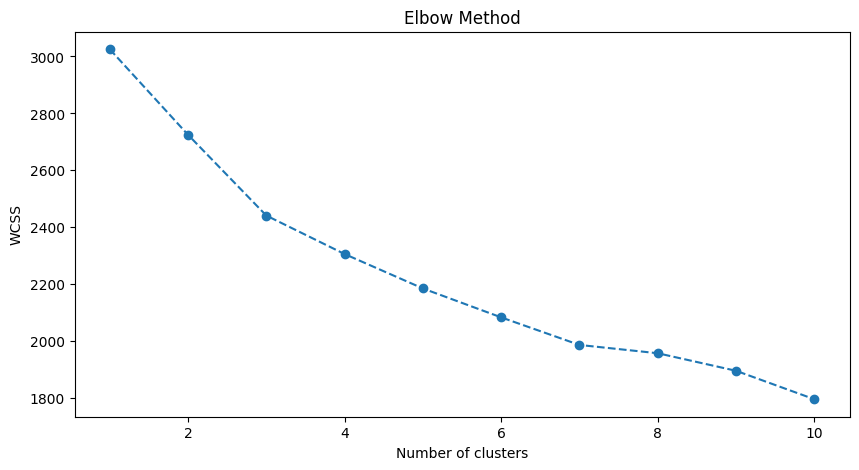

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt, numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap

ss = []
max_clusters = 10
for i in range(1, max_clusters+1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_df)
    # Inertia method returns WCSS for that model
    ss.append(kmeans.inertia_)

# Plot the Elbow method
plt.figure(figsize=(10,5))
plt.plot(range(1, max_clusters+1), ss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

- PCA can not keep the significant meaning of the data (the sum of explained_variance_ratio is too small)
- When applying Elbow method, we see there're no clear elbow points.
- Our hypothesis is that the data is sporadic, which means there're no clearly common patterns between data, and we can not cluster them into groups.

**Our suggestions for next steps:**

* We can collect more data of churned users: by collect real data or using our above supervised model to predict and use it as ground truth data for clustering model

* Business can offer the promotion for all churned users and collect results. These results can be used as features in the data for the next model.